# SignBridge: Probing VLM Understanding of American Sign Language

**Exploration question**: Do open-source vision-language models encode meaningful ASL gesture representations in their language decoder layers, and if so, where does that signal peak?

**What we do**:
1. Load ASL gesture images with gloss labels
2. Run LLaVA-1.5-7B on each image and extract residual-stream activations at layers 8, 16, 24, 31
3. Train linear probes on those activations to predict gloss category
4. Plot layer-by-layer probe accuracy to localize where sign information lives
5. UMAP-project activations to visualize representation geometry
6. Launch a Gradio demo with image upload + live webcam tabs

**Model**: LLaVA-1.5-7B loaded in 4-bit via bitsandbytes (~14 GB VRAM).  
**Dataset**: Sign Language MNIST via Kaggle
**Target hardware**: Colab H100 or G4 (T4 also works with batch_size=1).

## 0. Setup

Install all dependencies. bitsandbytes handles 4-bit quantization; umap-learn handles the projection visualization. accelerate is required for device_map='auto' with quantized models.

In [1]:
!pip install -q \
    transformers>=4.40.0 \
    bitsandbytes>=0.43.0 \
    accelerate>=0.29.0 \
    datasets>=2.18.0 \
    Pillow \
    scikit-learn \
    umap-learn \
    matplotlib \
    gradio>=4.26.0 \
    opencv-python-headless \
    huggingface_hub

In [2]:
import os, warnings, gc, json, time
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from collections import defaultdict

warnings.filterwarnings('ignore')

# Confirm GPU
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

CUDA available: True
GPU: NVIDIA H100 80GB HBM3
VRAM: 85.0 GB


In [3]:
from huggingface_hub import login
from google.colab import userdata
import os
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
# Paste your HuggingFace token when prompted, or set HF_TOKEN env var beforehand.
# Token needs read access only.
hf_token = os.environ.get('HF_TOKEN', None)
if hf_token:
    login(token=hf_token, add_to_git_credential=False)
    print('Logged in via env var.')
else:
    login()  # interactive prompt

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in via env var.


## 1. Data Loading

Dataset is Sign Language MNIST (Kaggle, CC0), loaded via CSV for speed. 34,627 samples across 24 ASL letter classes (A–Z minus J and Z)

In [6]:
# one-time download — runs in seconds
!pip install -q kaggle
!mkdir -p ~/.kaggle
from google.colab import userdata
import json, os

val = userdata.get('KAGGLE_KEY')

# handle either the full JSON or just the raw key string
try:
    kaggle_creds = json.loads(val)
except json.JSONDecodeError:
    # val is just the raw key, not the full JSON
    import getpass
    username = getpass.getpass('Enter your Kaggle username: ')
    kaggle_creds = {'username': username, 'key': val.strip()}

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle credentials written.')

Enter your Kaggle username: ··········
Kaggle credentials written.


In [10]:
!kaggle datasets download -d datamunge/sign-language-mnist -p /content/slmnist --unzip

Dataset URL: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
License(s): CC0-1.0
100% 62.6M/62.6M [00:00<00:00, 131MB/s]



In [11]:
import os
for root, dirs, files in os.walk('/content/slmnist'):
    for f in files:
        print(os.path.join(root, f))

/content/slmnist/amer_sign3.png
/content/slmnist/american_sign_language.PNG
/content/slmnist/sign_mnist_test.csv
/content/slmnist/sign_mnist_train.csv
/content/slmnist/amer_sign2.png
/content/slmnist/sign_mnist_train/sign_mnist_train.csv
/content/slmnist/sign_mnist_test/sign_mnist_test.csv


In [12]:
from PIL import Image
import numpy as np
import pandas as pd

DATASET_NAME = 'Sign-Language-MNIST'

label_map = {
    0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',
    10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',
    18:'S',19:'T',20:'U',21:'V',22:'W',23:'X',24:'Y'
}

train = pd.read_csv('/content/slmnist/sign_mnist_train.csv')
test  = pd.read_csv('/content/slmnist/sign_mnist_test.csv')
df = pd.concat([train, test], ignore_index=True)

pixel_cols = [c for c in df.columns if c.startswith('pixel')]
pixels = df[pixel_cols].values.astype(np.uint8).reshape(-1, 28, 28)
label_ints = df['label'].values

images_raw = [Image.fromarray(p).convert('RGB') for p in pixels]
labels_raw = [label_map.get(int(l), str(l)) for l in label_ints]

print(f'Loaded {len(images_raw)} samples, {len(set(labels_raw))} classes')

Loaded 34627 samples, 24 classes


In [16]:
from collections import Counter, defaultdict
import random

MAX_CLASSES = 20
MAX_SAMPLES_PER_CLASS = 15

random.seed(42)
np.random.seed(42)

class_counts = Counter(labels_raw)
valid_classes = [c for c, n in class_counts.most_common() if n >= 5]
selected_classes = valid_classes[:MAX_CLASSES]
label_names = sorted(selected_classes)
label2idx = {l: i for i, l in enumerate(label_names)}

class_buckets = defaultdict(list)
for img, lbl in zip(images_raw, labels_raw):
    if lbl in label2idx:
        class_buckets[lbl].append(img)

images, labels = [], []
for cls in label_names:
    bucket = class_buckets[cls]
    random.shuffle(bucket)
    for img in bucket[:MAX_SAMPLES_PER_CLASS]:
        images.append(img)
        labels.append(cls)

label_ids = [label2idx[l] for l in labels]

print(f'Final dataset: {len(images)} images across {len(label_names)} classes')
print('Classes:', label_names)

Final dataset: 300 images across 20 classes
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'Y']


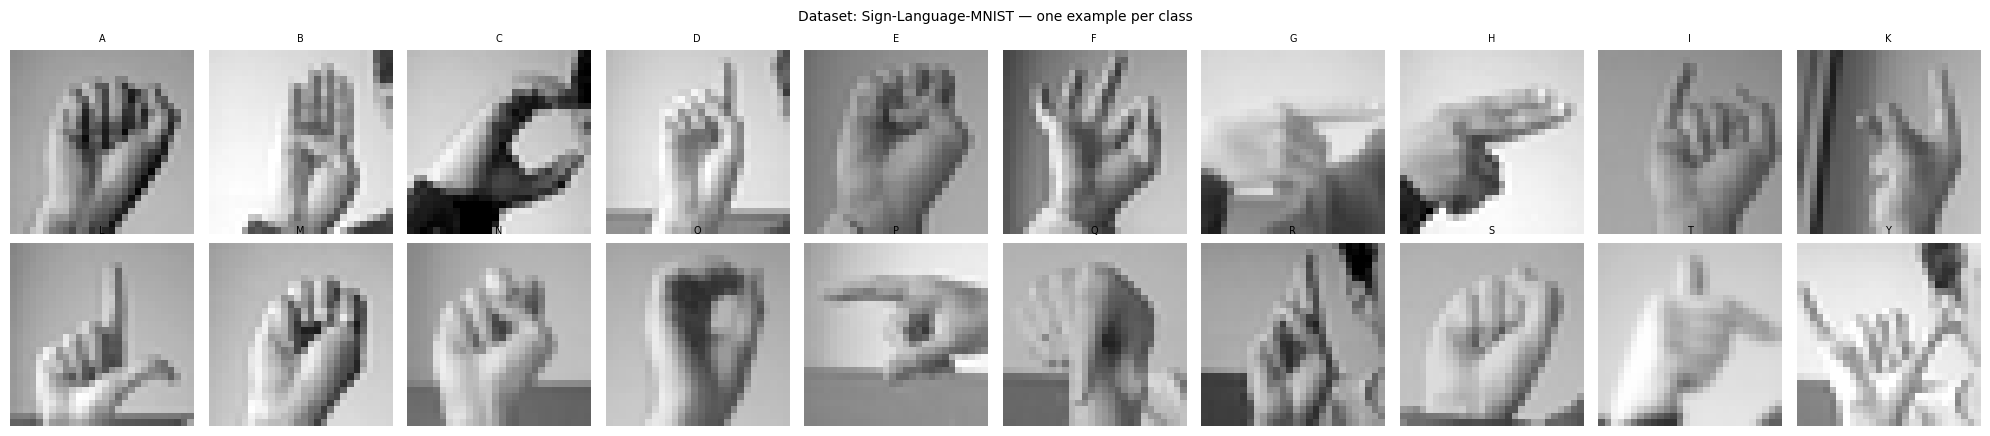

Saved class_grid.png


In [17]:
# Quick visual sanity check display one image per class in a grid
n = len(label_names)
cols = min(n, 10)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.2))
axes = np.array(axes).reshape(-1)

# find first image for each class
seen = {}
for img, lbl in zip(images, labels):
    if lbl not in seen:
        seen[lbl] = img

for ax, cls in zip(axes, label_names):
    ax.imshow(seen[cls])
    ax.set_title(cls, fontsize=7)
    ax.axis('off')
for ax in axes[len(label_names):]:
    ax.axis('off')

plt.suptitle(f'Dataset: {DATASET_NAME} — one example per class', fontsize=10)
plt.tight_layout()
plt.savefig('class_grid.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved class_grid.png')

## 2. Model Loading

We load LLaVA-1.5-7B in 4-bit NF4 quantization. The model is a Mistral-7B language backbone with a CLIP ViT-L/14@336 vision encoder bridged by a two-layer MLP projector. Quantizing the LM backbone with bitsandbytes cuts memory from ~28 GB to ~14 GB with minimal accuracy loss.

We register forward hooks on the language model's decoder layers to capture the hidden state (residual stream) at layers 8, 16, 24, and 31. These are the vectors we will probe.

In [30]:
from transformers import (
    LlavaForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)

MODEL_ID = 'llava-hf/llava-1.5-7b-hf'
PROBE_LAYERS = [8, 16, 24, 31]  # decoder layer indices to probe

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f'Loading {MODEL_ID}...')
t0 = time.time()

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)
model.eval()

print(f'Model loaded in {time.time()-t0:.1f}s')
print('GPU memory used:', round(torch.cuda.memory_allocated() / 1e9, 2), 'GB')

Loading llava-hf/llava-1.5-7b-hf...


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Model loaded in 6.0s
GPU memory used: 11.93 GB


In [31]:
# Locate the language model decoder layers so we can hook them.
# LLaVA-1.5 wraps a Mistral/Llama LM;
lm_layers = model.model.language_model.layers
total_layers = len(lm_layers)
print(f'Language model has {total_layers} decoder layers')

# Validate that requested probe layers exist
for pl in PROBE_LAYERS:
    assert pl < total_layers, f'Layer {pl} out of range (model has {total_layers} layers)'
print('Probe layers:', PROBE_LAYERS)

Language model has 32 decoder layers
Probe layers: [8, 16, 24, 31]


## 3. VLM Inference + Activation Extraction

For each image we:
1. Build a standard prompt: `"What sign is being made in this image?"`
2. Run a single forward pass (we generate up to 20 tokens)
3. Capture the hidden state at the last token position for each probe layer via a registered hook
4. Store the response text and the four activation vectors

The last-token position is the model's summary of the full input context, so it is the best single-vector representation for probing.

In [38]:
PROMPT_TEMPLATE = 'USER: <image>\nWhat sign is being made in this image? Answer with one word.\nASSISTANT:'
MAX_NEW_TOKENS = 20  # short generation; we only need the VLM text output

# Storage
all_activations = {layer: [] for layer in PROBE_LAYERS}  # layer -> list of np vectors
all_responses = []  # VLM text responses

# Hook storage — filled during each forward pass
_hook_cache = {}

def make_hook(layer_idx):
    """Return a hook that saves the output hidden state of decoder layer layer_idx."""
    def hook(module, input, output):
        # output is a tuple; first element is the hidden state tensor [batch, seq_len, hidden_dim]
        hidden = output[0]  # [1, seq_len, hidden_dim]
        # take the last token position — the model's full-context summary
        vec = hidden[0, -1, :].detach().float().cpu().numpy()
        _hook_cache[layer_idx] = vec
    return hook

# Register hooks
hooks = []
for layer_idx in PROBE_LAYERS:
    h = lm_layers[layer_idx].register_forward_hook(make_hook(layer_idx))
    hooks.append(h)

print('Hooks registered on layers:', PROBE_LAYERS)

Hooks registered on layers: [8, 16, 24, 31]


In [40]:
# clear all existing hooks
import torch.nn as nn

for module in model.modules():
    module._forward_hooks.clear()

print('All hooks cleared.')

All hooks cleared.


In [41]:
_hook_cache = {}

def make_hook(layer_idx):
    def hook(module, input, output):
        hidden = output[0]
        arr = hidden.detach().float().cpu()
        # output is [seq_len, hidden_dim] (no batch dim in this model)
        vec = arr[-1, :].numpy()
        _hook_cache[layer_idx] = vec
    return hook

hooks = []
for layer_idx in PROBE_LAYERS:
    h = lm_layers[layer_idx].register_forward_hook(make_hook(layer_idx))
    hooks.append(h)

all_activations = {layer: [] for layer in PROBE_LAYERS}
all_responses = []

print(f'Running inference on {len(images)} images...')
t0 = time.time()

for i, (img, lbl) in enumerate(zip(images, labels)):
    _hook_cache.clear()

    inputs = processor(
        text=PROMPT_TEMPLATE,
        images=img,
        return_tensors='pt',
    ).to(model.device, dtype=torch.float16)

    with torch.inference_mode():
        output_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)

    generated = output_ids[0, inputs['input_ids'].shape[1]:]
    response = processor.decode(generated, skip_special_tokens=True).strip()
    all_responses.append(response)

    for layer_idx in PROBE_LAYERS:
        vec = _hook_cache.get(layer_idx)
        if vec is None:
            vec = np.zeros(model.config.text_config.hidden_size)
        all_activations[layer_idx].append(vec)

    if (i + 1) % 20 == 0 or i == len(images) - 1:
        elapsed = time.time() - t0
        print(f'  [{i+1}/{len(images)}] elapsed {elapsed:.0f}s | last response: "{response}" | label: {lbl}')

for h in hooks:
    h.remove()

print('Inference complete.')

Running inference on 300 images...
  [20/300] elapsed 3s | last response: "None" | label: B
  [40/300] elapsed 5s | last response: "Hand" | label: C
  [60/300] elapsed 7s | last response: "Point" | label: D
  [80/300] elapsed 10s | last response: "O" | label: F
  [100/300] elapsed 12s | last response: "Point" | label: G
  [120/300] elapsed 14s | last response: "Point" | label: H
  [140/300] elapsed 16s | last response: "Peace" | label: K
  [160/300] elapsed 19s | last response: "L" | label: L
  [180/300] elapsed 21s | last response: "Fist" | label: M
  [200/300] elapsed 23s | last response: "Peace" | label: O
  [220/300] elapsed 26s | last response: "Point" | label: P
  [240/300] elapsed 28s | last response: "Hand" | label: Q
  [260/300] elapsed 31s | last response: "Fist" | label: S
  [280/300] elapsed 33s | last response: "Point" | label: T
  [300/300] elapsed 36s | last response: "Rock and roll" | label: Y
Inference complete.


In [42]:
# Convert activation lists to numpy arrays: shape [N, hidden_dim]
act_arrays = {layer: np.stack(vecs) for layer, vecs in all_activations.items()}
label_ids_arr = np.array(label_ids)

for layer, arr in act_arrays.items():
    print(f'Layer {layer}: activations shape {arr.shape}')

# Save to disk so we don't need to re-run inference if the kernel restarts
np.savez('signbridge_activations.npz', **{f'layer_{k}': v for k, v in act_arrays.items()})
np.save('signbridge_label_ids.npy', label_ids_arr)
with open('signbridge_metadata.json', 'w') as f:
    json.dump({
        'label_names': label_names,
        'labels': labels,
        'responses': all_responses,
        'dataset': DATASET_NAME,
        'probe_layers': PROBE_LAYERS,
    }, f, indent=2)
print('Activations saved.')

Layer 8: activations shape (300, 4096)
Layer 16: activations shape (300, 4096)
Layer 24: activations shape (300, 4096)
Layer 31: activations shape (300, 4096)
Activations saved.


## 4. Linear Probe Training

A linear probe is the standard mechanistic interpretability tool for asking: "Is class X linearly decodable from this representation?". We train L2-regularised logistic regression on each layer's activations using 80/20 stratified splits. High accuracy means the information is present and linearly encoded i.e., the model has computed a clean, usable representation of the sign.

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

probe_results = {}  # layer_idx -> {accuracy, probe, scaler}

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for layer in PROBE_LAYERS:
    X = act_arrays[layer]   # [N, hidden_dim]
    y = label_ids_arr       # [N]

    train_idx, test_idx = next(sss.split(X, y))
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Standardise — logistic regression benefits from zero-mean unit-variance features
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial',
        random_state=42,
        n_jobs=-1,
    )
    clf.fit(X_train_s, y_train)
    preds = clf.predict(X_test_s)
    acc = accuracy_score(y_test, preds)

    probe_results[layer] = {'accuracy': acc, 'probe': clf, 'scaler': scaler}
    print(f'Layer {layer:2d} probe accuracy: {acc:.3f} ({int(acc * len(y_test))}/{len(y_test)} correct)')

Layer  8 probe accuracy: 0.717 (43/60 correct)
Layer 16 probe accuracy: 0.817 (49/60 correct)
Layer 24 probe accuracy: 0.767 (46/60 correct)
Layer 31 probe accuracy: 0.733 (44/60 correct)


## 5. Analysis and Visualizations

### 5a. Layer-by-layer accuracy curve

This plot answers the main research question: which decoder layer contains the most sign-language-relevant information? A peak at deeper layers suggests sign meaning is constructed progressively through the network. A flat curve suggests the signal is either absent or dominated by low-level visual features passed through unchanged.

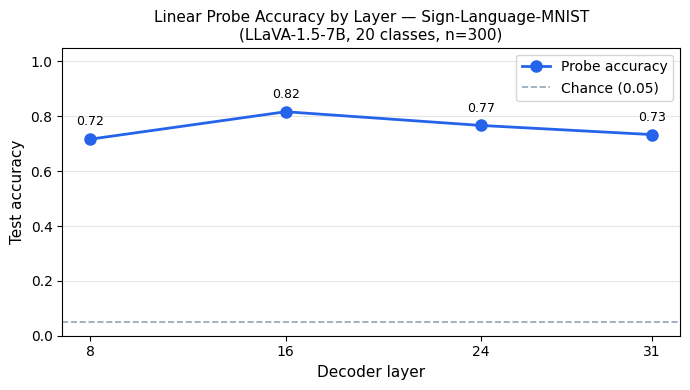

Saved probe_accuracy_curve.png
Peak probe accuracy at layer 16: 0.817


In [44]:
accs = [probe_results[l]['accuracy'] for l in PROBE_LAYERS]
chance = 1.0 / len(label_names)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(PROBE_LAYERS, accs, marker='o', linewidth=2, markersize=8, color='#2563EB', label='Probe accuracy')
ax.axhline(chance, linestyle='--', color='#94A3B8', linewidth=1.2, label=f'Chance ({chance:.2f})')

# annotate each point
for layer, acc in zip(PROBE_LAYERS, accs):
    ax.annotate(f'{acc:.2f}', (layer, acc), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

ax.set_xlabel('Decoder layer', fontsize=11)
ax.set_ylabel('Test accuracy', fontsize=11)
ax.set_title(f'Linear Probe Accuracy by Layer — {DATASET_NAME}\n(LLaVA-1.5-7B, {len(label_names)} classes, n={len(images)})', fontsize=11)
ax.set_xticks(PROBE_LAYERS)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('probe_accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved probe_accuracy_curve.png')

best_layer = PROBE_LAYERS[np.argmax(accs)]
print(f'Peak probe accuracy at layer {best_layer}: {max(accs):.3f}')

### 5b. UMAP projection of activations

We project the best-performing layer's activations down to 2D with UMAP and colour each point by its gloss class. Tight, well-separated clusters indicate that the model has constructed geometry-respecting sign representations. Overlapping blobs indicate poor or absent discrimination.

Running UMAP on layer 16 activations ((300, 4096))...


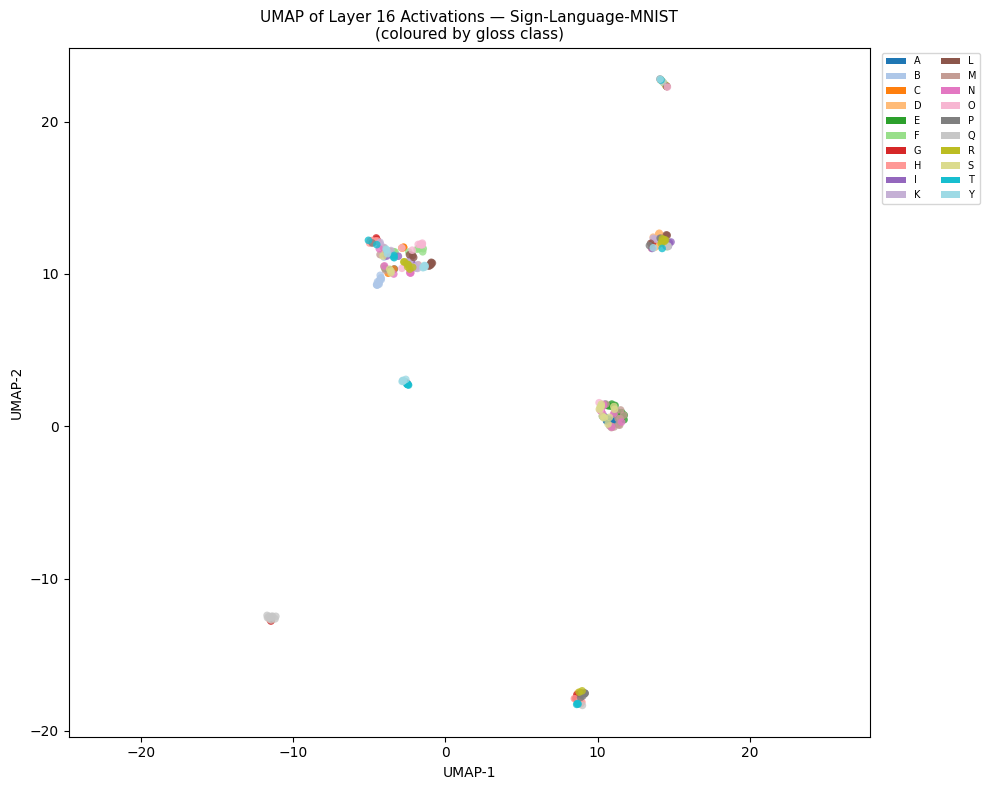

Saved umap_projection.png


In [45]:
import umap

# Use the best probe layer for the UMAP
best_X = act_arrays[best_layer]  # [N, hidden_dim]

print(f'Running UMAP on layer {best_layer} activations ({best_X.shape})...')
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42, verbose=False)
embedding = reducer.fit_transform(best_X)  # [N, 2]

# Colour map — one colour per class
cmap = cm.get_cmap('tab20', len(label_names))
colors = [cmap(label2idx[l]) for l in labels]

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=30, alpha=0.8, linewidths=0)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cmap(i), label=cls) for i, cls in enumerate(label_names)]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=7, framealpha=0.8, ncol=1 + len(label_names) // 20)

ax.set_title(f'UMAP of Layer {best_layer} Activations — {DATASET_NAME}\n(coloured by gloss class)', fontsize=11)
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.axis('equal')
plt.tight_layout()
plt.savefig('umap_projection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved umap_projection.png')

In [46]:
# --- Summary statistics ---
print('=== SignBridge Results Summary ===')
print(f'Dataset      : {DATASET_NAME}')
print(f'Classes      : {len(label_names)}')
print(f'Total samples: {len(images)}')
print(f'Chance level : {chance:.3f}')
print()
for layer, acc in zip(PROBE_LAYERS, accs):
    bar = '#' * int(acc * 40)
    print(f'Layer {layer:2d}: {acc:.3f}  {bar}')
print()
print(f'Best layer   : {best_layer} (accuracy {max(accs):.3f})')
print(f'Gain vs chance: +{max(accs) - chance:.3f}')

=== SignBridge Results Summary ===
Dataset      : Sign-Language-MNIST
Classes      : 20
Total samples: 300
Chance level : 0.050

Layer  8: 0.717  ############################
Layer 16: 0.817  ################################
Layer 24: 0.767  ##############################
Layer 31: 0.733  #############################

Best layer   : 16 (accuracy 0.817)
Gain vs chance: +0.767


## 6. Gradio Demo

Two-tab interface:
- **Tab A Image Upload**: user uploads an image, gets the VLM text response plus a bar chart showing probe confidence for each probe layer.
- **Tab B Webcam**: captures a frame from the webcam, runs the same pipeline, displays results.

logistic regression probability (not softmax. sklearn predict_proba uses the probe's own probability calibration): a simple summary of how confidently each layer can classify the sign.

In [56]:
import gradio as gr
import matplotlib
import matplotlib.gridspec as gridspec
matplotlib.use('Agg')


def run_inference(pil_image):
    if pil_image is None:
        return 'No image provided.', None

    for module in model.modules():
        module._forward_hooks.clear()

    pil_image = pil_image.convert('RGB')

    local_cache = {}

    def make_local_hook(lidx):
        def hook(module, input, output):
            hidden = output[0]
            arr = hidden.detach().float().cpu()
            vec = arr[-1, :].numpy() if arr.dim() == 2 else arr[0, -1, :].numpy()
            local_cache[lidx] = vec
        return hook

    hs = [lm_layers[li].register_forward_hook(make_local_hook(li)) for li in PROBE_LAYERS]

    inputs = processor(
        text=PROMPT_TEMPLATE,
        images=pil_image,
        return_tensors='pt',
    ).to(model.device, dtype=torch.float16)

    with torch.inference_mode():
        out_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)

    for h in hs:
        h.remove()

    generated = out_ids[0, inputs['input_ids'].shape[1]:]
    response = processor.decode(generated, skip_special_tokens=True).strip()

    # --- run probes ---
    layer_predictions = []
    all_probas = {}
    for layer in PROBE_LAYERS:
        vec = local_cache.get(layer)
        if vec is None:
            layer_predictions.append((layer, 'N/A', 0.0))
            all_probas[layer] = np.zeros(len(label_names))
            continue
        result = probe_results[layer]
        vec_s = result['scaler'].transform(vec.reshape(1, -1))
        proba = result['probe'].predict_proba(vec_s)[0]
        top_idx = np.argmax(proba)
        layer_predictions.append((layer, label_names[top_idx], proba[top_idx]))
        all_probas[layer] = proba

    # ---- build figure with 3 panels ----
    fig = plt.figure(figsize=(14, 10), facecolor='#0f1117')
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    text_color = '#e0e0e0'
    accent = '#4f8ef7'
    grid_color = '#2a2a3a'

    # --- Panel 1: horizontal confidence bars per layer ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_facecolor('#1a1a2e')
    layer_labels = [f'Layer {l}' for l, _, _ in layer_predictions]
    confidences = [c for _, _, c in layer_predictions]
    predicted_classes = [cls for _, cls, _ in layer_predictions]
    colors = [accent if c == max(confidences) else '#3a5a9a' for c in confidences]
    bars = ax1.barh(layer_labels, confidences, color=colors, edgecolor='none', height=0.5)
    for bar, cls, conf in zip(bars, predicted_classes, confidences):
        ax1.text(conf + 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{cls} ({conf:.2f})', va='center', fontsize=8, color=text_color)
    ax1.axvline(1.0 / len(label_names), linestyle='--', color='#ff6b6b', linewidth=1, label='chance')
    ax1.set_xlim(0, 1.3)
    ax1.set_xlabel('Top-class confidence', color=text_color, fontsize=9)
    ax1.set_title('Layer-wise Probe Confidence', color=text_color, fontsize=10, fontweight='bold')
    ax1.tick_params(colors=text_color)
    ax1.spines[:].set_color(grid_color)
    ax1.legend(fontsize=7, labelcolor=text_color, facecolor='#1a1a2e', edgecolor=grid_color)

    # --- Panel 2: top-5 class probability distribution at best layer ---
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_facecolor('#1a1a2e')
    best_proba = all_probas[best_layer]
    top5_idx = np.argsort(best_proba)[-5:][::-1]
    top5_labels = [label_names[i] for i in top5_idx]
    top5_vals = [best_proba[i] for i in top5_idx]
    bar_colors = ['#f7c948' if i == 0 else accent for i in range(5)]
    ax2.bar(top5_labels, top5_vals, color=bar_colors, edgecolor='none', width=0.6)
    ax2.set_ylabel('Probability', color=text_color, fontsize=9)
    ax2.set_title(f'Top-5 Class Probabilities (Layer {best_layer})', color=text_color, fontsize=10, fontweight='bold')
    ax2.tick_params(colors=text_color)
    ax2.spines[:].set_color(grid_color)
    ax2.set_ylim(0, 1.05)
    for spine in ax2.spines.values():
        spine.set_color(grid_color)

    # --- Panel 3: probability heatmap across all layers x top-8 classes ---
    ax3 = fig.add_subplot(gs[1, :])
    ax3.set_facecolor('#1a1a2e')
    # pick top 8 classes by max probability across any layer
    max_proba_per_class = np.max(np.stack(list(all_probas.values())), axis=0)
    top8_idx = np.argsort(max_proba_per_class)[-8:][::-1]
    top8_labels = [label_names[i] for i in top8_idx]
    heatmap_data = np.array([[all_probas[l][i] for i in top8_idx] for l in PROBE_LAYERS])
    im = ax3.imshow(heatmap_data, aspect='auto', cmap='Blues', vmin=0, vmax=heatmap_data.max())
    ax3.set_xticks(range(len(top8_labels)))
    ax3.set_xticklabels(top8_labels, color=text_color, fontsize=10)
    ax3.set_yticks(range(len(PROBE_LAYERS)))
    ax3.set_yticklabels([f'Layer {l}' for l in PROBE_LAYERS], color=text_color, fontsize=9)
    ax3.set_title('Probe Probability Heatmap — All Layers × Top-8 Classes', color=text_color, fontsize=10, fontweight='bold')
    # annotate cells
    for row in range(len(PROBE_LAYERS)):
        for col in range(len(top8_labels)):
            val = heatmap_data[row, col]
            ax3.text(col, row, f'{val:.2f}', ha='center', va='center',
                     fontsize=8, color='white' if val > heatmap_data.max() * 0.5 else '#aaaaaa')
    cbar = fig.colorbar(im, ax=ax3, fraction=0.02, pad=0.02)
    cbar.ax.tick_params(colors=text_color)

    # main title
    fig.suptitle(f'SignBridge Analysis — VLM response: "{response}"',
                 color=text_color, fontsize=12, fontweight='bold', y=0.98)

    fig.canvas.draw()
    buf = fig.canvas.buffer_rgba()
    w, h = fig.canvas.get_width_height()
    chart_img = Image.frombytes('RGBA', (w, h), buf).convert('RGB')
    plt.close(fig)

    return response, chart_img


print('Inference function defined.')

Inference function defined.


In [58]:
# Build Gradio interface

with gr.Blocks(title='SignBridge') as demo:
    gr.Markdown(
        '# SignBridge\n'
        f'**Probing LLaVA-1.5-7B for ASL / Gesture Understanding — Dataset: {DATASET_NAME}**\n\n'
        'Upload an image or use your webcam. The model will describe the sign and show '
        'how confidently each decoder layer can identify it.'
    )

    with gr.Tab('Upload Image'):
        with gr.Row():
            with gr.Column(scale=1):
                img_input = gr.Image(
                    label='Input image',
                    type='pil',
                    sources=['upload', 'clipboard'],
                )
                upload_btn = gr.Button('Analyse', variant='primary')
            with gr.Column(scale=2):
                vlm_output = gr.Textbox(label='VLM response', lines=2)
                chart_output = gr.Image(label='Layer-wise probe confidence')

        upload_btn.click(
            fn=run_inference,
            inputs=[img_input],
            outputs=[vlm_output, chart_output],
        )

    with gr.Tab('Webcam'):
        gr.Markdown(
            'Click **Capture** to grab a frame from your webcam, then **Analyse** to run inference.'
        )
        with gr.Row():
            with gr.Column(scale=1):
                webcam_input = gr.Image(
                    label='Webcam',
                    type='pil',
                    sources=['webcam'],
                    streaming=False,  # single-shot capture
                )
                webcam_btn = gr.Button('Analyse', variant='primary')
            with gr.Column(scale=2):
                webcam_vlm_output = gr.Textbox(label='VLM response', lines=2)
                webcam_chart_output = gr.Image(label='Layer-wise probe confidence')

        webcam_btn.click(
            fn=run_inference,
            inputs=[webcam_input],
            outputs=[webcam_vlm_output, webcam_chart_output],
        )

    gr.Markdown(
        '---\n'
        f'**Classes probed ({len(label_names)})**: {', '.join(label_names)}\n\n'
        f'**Best probe layer**: {best_layer} (accuracy {max(accs):.3f})'
    )
    gr.Markdown(
    '> **Note**: The VLM response reflects natural-language generation (e.g. "finger", "peace sign"). '
    'The probe predictions decode latent ASL structure directly from hidden states — '
    'these often diverge, which is itself the key finding: '
    'the network encodes sign-discriminative geometry that never surfaces in its text output.'
)

print('Launching Gradio demo...')
demo.launch(
    share=True,      # creates a public link; set False if you prefer local only
    debug=False,
    show_error=True,
)

Launching Gradio demo...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://38c1217eba87a04fff.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
